# CS-RHF Result comparison 
Results of the implementation compared to those obtained with [Qchem](https://doi.org/10.1080/00268976.2014.952696). 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
from pyscf import gto
from py_mods.src.SCF.basis_utils import even_temp_uncontr_str
from py_mods.src.SCF.CSRHF import theta_traj

# 2s1 Helium 
## Even-tempered basis

In [2]:
He_tempered_str = even_temp_uncontr_str('He', 'S', 7.668876968794860E-002, 1.9581497063588078, 21) # because this is the reference data 

mol_He_even= gto.M(atom = 'He 0 0 0', spin=0, charge=0,) # basis='aug-cc-pVqZ')

mol_He_even.basis = {'He': gto.basis.parse(He_tempered_str)}
mol_He_even.build()

T_even_H2 = mol_He_even.intor('int1e_kin')
V_even_H2 = mol_He_even.intor('int1e_nuc')
S_even_H2 = mol_He_even.intor('int1e_ovlp')
eri_even_H2 = mol_He_even.intor('int2e')


-2.568 0.672000000000001


In [3]:
max_theta = 0.08 # because we have this data for reference
n_points = 9

traj_energies = theta_traj(max_theta, n_points, S_even_H2, T_even_H2, V_even_H2, eri_even_H2, 2, max_iter=1000, threshold=2E-10, p_guess='core', verbose=True, conv_type='CROP')
traj_ener = np.array(traj_energies[1], dtype=complex)
# plot_theta_traj(traj_energies[1]) 
print(traj_energies[1])

#[np.complex128(-2.861679925245534+0j), np.complex128(-2.861719846329826+0.010257634582459848j), np.complex128(-2.861839612725852+0.02051493414429964j), np.complex128(-2.8620392338592446+0.030771563392121188j), np.complex128(-2.862318725426466+0.04102718648721291j), np.complex128(-2.8626781093755214+0.051281466773505466j), np.complex128(-2.8631174138788884+0.06153406650625293j), np.complex128(-2.863636673298766+0.0717846465816811j), np.complex128(-2.8642359281446717+0.08203286626783605j)]

--------------------------------------------------------------------------------------------------------------------------------
|   Iter   |               E_iter                  |                       Delta_e                   |        norm(e_i)        |
--------------------------------------------------------------------------------------------------------------------------------
    0            0.0000000000000000+0.0000000000000000j            0.0000000000000000+0.0000000000000000j     0.0000E+00
    1           -2.7499999355356337+0.0000000000000000j           -2.7499999355356337+0.0000000000000000j     3.9875E+00
    2           -2.8603020771569470+0.0000000000000000j           -0.1103021416213132+0.0000000000000000j     2.6132E-01
    3           -2.8616457205961403+0.0000000000000000j           -0.0013436434391934+0.0000000000000000j     3.3606E-02
    4           -2.8616786303215056+0.0000000000000000j           -0.0000329097253653+0.0000000000000000j     6.0509E-03
    5   

In [4]:
def load_traj(filename):
    with open(filename) as f:
        cont = f.readlines()
    cont = [line.strip().replace('(', '').replace(')','') for line in cont]
    thetas = np.array([int(line.split(';')[0]) for line in cont])
    eners = [line.split(';')[1].strip().replace(' ', '').replace(',','+').replace('+-', '-') +'j' for line in cont]
    eners = np.array([complex(a) for a in eners])

    return thetas, eners

In [5]:
w, k = load_traj('data/CSHF_QCHEM/He_1s2_eventemp_qchem.dat')

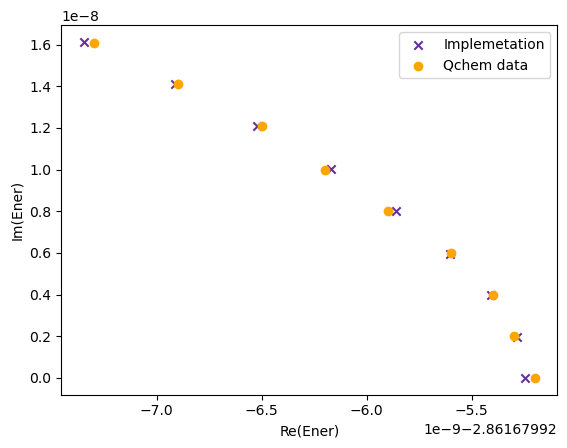

In [6]:
plt.scatter(traj_ener.real, traj_ener.imag,label='Implemetation', c='RebeccaPurple', marker='x')
plt.scatter(k.real, k.imag, label='Qchem data', marker='o', c='orange')
plt.legend()
plt.xlabel('Re(Ener)')
plt.ylabel('Im(Ener)')
plt.show()

In [7]:
error = traj_ener-k
print(f'Mean error: {np.mean(error): 6.4E}')
print(f'Max error:  {np.max(error): 6.4E}')

Mean error: -6.0174E-12-5.2933E-12j
Max error:   4.0631E-11-8.2105E-12j


## Augmented aug-cc-pV5Z

In [8]:
large_basis = '''
He    S
      5.285000E+02           0.000000E+00           9.400000E-04           0.000000E+00           0.000000E+00
      7.931000E+01           0.000000E+00           7.214000E-03           0.000000E+00           0.000000E+00
      1.805000E+01           0.000000E+00           3.597500E-02           0.000000E+00           0.000000E+00
      5.085000E+00           0.000000E+00           1.277820E-01           0.000000E+00           0.000000E+00
      1.609000E+00           1.000000E+00           3.084700E-01           0.000000E+00           0.000000E+00
      5.363000E-01           0.000000E+00           4.530520E-01           1.000000E+00           0.000000E+00
      1.833000E-01           0.000000E+00           2.388840E-01           0.000000E+00           1.000000E+00
He    S
      0.0481900              1.0000000
He    P
      5.994000E+00           1.000000E+00           0.000000E+00           0.000000E+00
      1.745000E+00           0.000000E+00           1.000000E+00           0.000000E+00
      5.600000E-01           0.000000E+00           0.000000E+00           1.000000E+00
He    P
      0.1626000              1.0000000
He    D
      4.299000E+00           1.000000E+00           0.000000E+00
      1.223000E+00           0.000000E+00           1.000000E+00
He    D
      0.3510000              1.0000000
He    F
      2.680000E+00           1.0000000
He    F
      0.6906000              1.0000000
END
'''

mol_He_even= gto.M(atom = 'He 0 0 0', spin=0, charge=0,) # basis='aug-cc-pVqZ')

mol_He_even.basis = {'He': gto.basis.parse(large_basis)}
mol_He_even.build()

T_even_H2 = mol_He_even.intor('int1e_kin')
V_even_H2 = mol_He_even.intor('int1e_nuc')
S_even_H2 = mol_He_even.intor('int1e_ovlp')
eri_even_H2 = mol_He_even.intor('int2e')


In [9]:
max_theta = 0.08 # because we have this data for reference
n_points = 9

traj_energies = theta_traj(max_theta, n_points, S_even_H2, T_even_H2, V_even_H2, eri_even_H2, 2, max_iter=100, threshold=1E-12, p_guess='core', verbose=False, conv_type='CROP')
traj_ener = np.array(traj_energies[1], dtype=complex)
#plot_theta_traj(traj_energies[1]) 
#print(traj_energies[1])

In [10]:
w, k = load_traj('data/CSHF_QCHEM/He_1s2_augqz_qchem.dat')

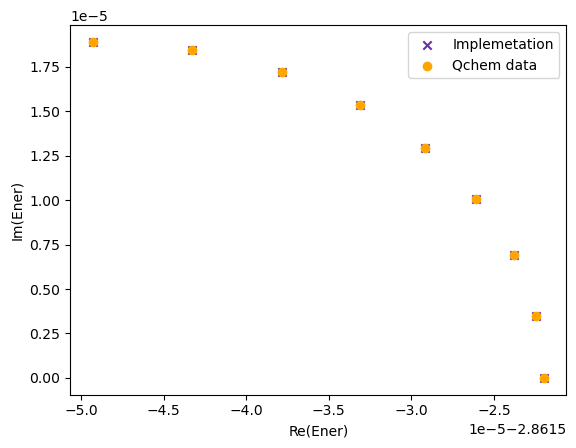

In [11]:
plt.scatter(traj_ener.real, traj_ener.imag,label='Implemetation', c='RebeccaPurple', marker='x')
plt.scatter(k.real, k.imag, label='Qchem data', marker='o', c='orange')
plt.legend()
plt.xlabel('Re(Ener)')
plt.ylabel('Im(Ener)')
plt.show()

In [12]:
error = traj_ener-k
print(f'Mean error: {np.mean(error): 6.4E}')
print(f'Max error:  {np.max(error): 6.4E}')

Mean error:  3.5073E-13+3.4948E-12j
Max error:   3.4038E-11+1.0237E-11j


# 2s2
## Even-tempered

In [13]:
He_tempered_str = even_temp_uncontr_str('He', 'S', 7.668876968794860E-002, 1.9581497063588078, 21) # because this is the reference data 

mol_He_even= gto.M(atom = 'He 0 0 0', spin=0, charge=0,) # basis='aug-cc-pVqZ')

mol_He_even.basis = {'He': gto.basis.parse(He_tempered_str)}
mol_He_even.build()

T_even_H2 = mol_He_even.intor('int1e_kin')
V_even_H2 = mol_He_even.intor('int1e_nuc')
S_even_H2 = mol_He_even.intor('int1e_ovlp')
eri_even_H2 = mol_He_even.intor('int2e')

-2.568 0.672000000000001


In [14]:
max_theta = 0.40 # because we have this data for reference
n_points = 41

traj_energies = theta_traj(max_theta, n_points, S_even_H2, T_even_H2, V_even_H2, eri_even_H2, 2, occupation=np.array([0,2,0]) ,max_iter=400, threshold=1E-10, p_guess='core', verbose=False)
traj_ener = np.array(traj_energies[1], dtype=complex)
#print(traj_ener)


In [15]:
w, k = load_traj('data/CSHF_QCHEM/He_2s2_eventemp_qchem.dat')

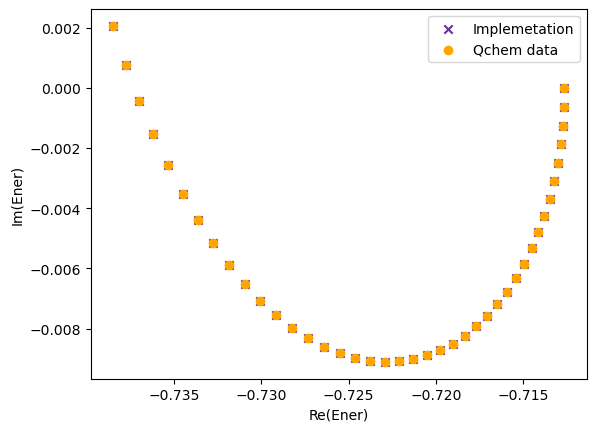

In [16]:
plt.scatter(traj_ener.real, traj_ener.imag,label='Implemetation', c='RebeccaPurple', marker='x')
plt.scatter(k.real, k.imag, label='Qchem data', marker='o', c='orange')
plt.legend()
plt.xlabel('Re(Ener)')
plt.ylabel('Im(Ener)')
plt.show()

In [17]:
error = traj_ener-k
print(f'Mean error: {np.mean(error): 6.4E}')
print(f'Max error:  {np.max(error): 6.4E}')

Mean error:  5.1172E-13+1.1569E-12j
Max error:   5.1040E-11-4.5331E-11j


## 2s2 aug-cc-pV5Z

In [18]:
mol_He_even= gto.M(atom = 'He 0 0 0', spin=0, charge=0,) # basis='aug-cc-pVqZ')

mol_He_even.basis = {'He': gto.basis.parse(large_basis)}
mol_He_even.build()

T_even_H2 = mol_He_even.intor('int1e_kin')
V_even_H2 = mol_He_even.intor('int1e_nuc')
S_even_H2 = mol_He_even.intor('int1e_ovlp')
eri_even_H2 = mol_He_even.intor('int2e')

In [19]:
max_theta = 0.08 # because we have this data for reference
n_points = 9

traj_energies = theta_traj(max_theta, n_points, S_even_H2, T_even_H2, V_even_H2, eri_even_H2, 2, occupation=np.array([0,2,0]) ,max_iter=100, threshold=1E-12, p_guess='core', verbose=False)
traj_ener = np.array(traj_energies[1], dtype=complex)
#print(traj_ener)

In [20]:
w, k = load_traj('data/CSHF_QCHEM/He_2s2_augqz_qchem.dat')

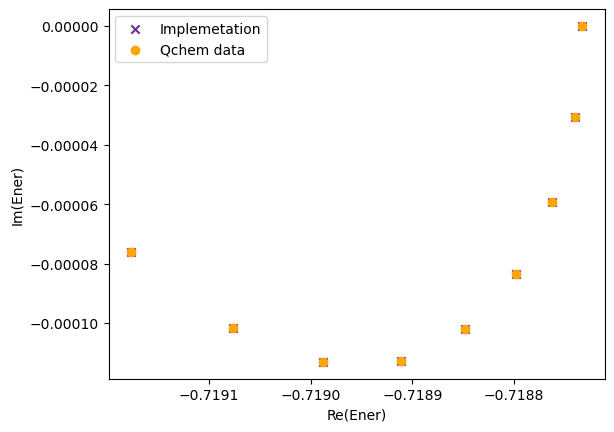

In [21]:
plt.scatter(traj_ener.real, traj_ener.imag,label='Implemetation', c='RebeccaPurple', marker='x')
plt.scatter(k.real, k.imag, label='Qchem data', marker='o', c='orange')
plt.legend()
plt.xlabel('Re(Ener)')
plt.ylabel('Im(Ener)')
#plt.xlim([-0.7191, -0.7190])
plt.show()

In [22]:
error = traj_ener-k
print(f'Mean error: {np.mean(error): 6.4E}')
print(f'Max error:  {np.max(error): 6.4E}')

Mean error:  1.2430E-12-4.9267E-12j
Max error:   4.6792E-11+4.7672E-11j
